In [2]:
import cv2
import os

img_dir = 'Croptimal/resnet/train/'

class_subdirs = [
    # Class 0
    # (subdir, weight)
    [('256_class_0', 1.0)],
    # Class 1
    [('256_class_1', 1.0)]]

n_classes = len(class_subdirs)
global_imgs = []

for i, class_data in enumerate(class_subdirs):
    global_imgs.append([])
    for subdir, weight in class_data:
        class_path = os.path.join(img_dir, subdir)
        for img_file in os.listdir(class_path):
            if img_file.endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                img_path = os.path.join(class_path, img_file)
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                if img is not None:
                    global_imgs[i].append(img)

for i in range(n_classes):
    print(f'Loaded {len(global_imgs[i])} images for class {i}')



Loaded 2258 images for class 0
Loaded 1390 images for class 1


In [3]:
import numpy as np
hist_0 = np.zeros((180, 256), dtype=np.float32)
hist_1 = np.zeros((180, 256), dtype=np.float32)
hue=[30, 50]
saturation=[120, 240]
count_range_0 = 0
count_range_1 = 0
remainingPixelCount = 0
totalPixelCount = 0
for label in range(n_classes):
    for img in global_imgs[label]:
        # convert image to HLS
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        # make histogram of H and S values
        hist = cv2.calcHist([hsv], [0, 1], None, [180, 256], [0, 180, 0, 256])
        if label == 0:
            hist_0 += hist
        else:
            hist_1 += hist
        mask = (
            (hsv[:, :, 0] >= hue[0]) & (hsv[:, :, 0] <= hue[1]) &
            (hsv[:, :, 1] >= saturation[0]) & (hsv[:, :, 1] <= saturation[1])
        )
        # filtered_img = img * mask[..., None]
        remainingPixelCount += mask.sum()
        totalPixelCount += mask.size
        if mask.any():
            if label == 0:
                count_range_0 += 1
            else:
                count_range_1 += 1

print(f'Class 0 images in range: {count_range_0}')
print(f'Class 1 images in range: {count_range_1}')
print(f'Remaining pixel count in range: {remainingPixelCount}')
print(f'Total pixel count: {totalPixelCount}')
print(f'Percentage of pixels in range: {100 * remainingPixelCount / totalPixelCount:.2f}%')
# normalize histograms
hist_0 = cv2.normalize(hist_0, hist_0).flatten()
hist_1 = cv2.normalize(hist_1, hist_1).flatten()

Class 0 images in range: 2258
Class 1 images in range: 1390
Remaining pixel count in range: 202752682
Total pixel count: 239075328
Percentage of pixels in range: 84.81%


Text(0.5, 1.0, 'Hue vs Saturation Histogram Comparison')

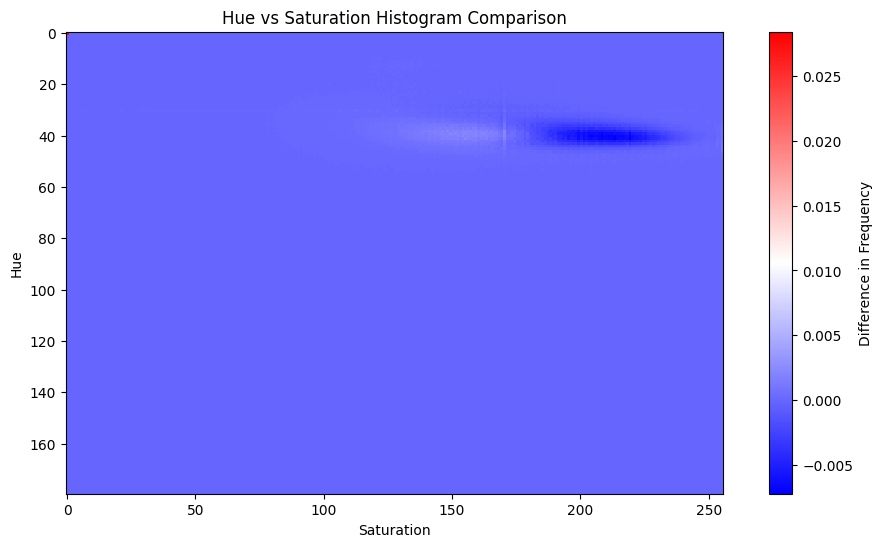

In [4]:
# plot histograms
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
# plot both histograms on same plot by subtracting one from the other as 2D histogram
np.save('histogram_diff.npy', (hist_0 - hist_1).reshape(180, 256))
# save the difference histogram in a file

plt.imsave('difference_histogram.png', (hist_0 - hist_1).reshape(180, 256), cmap='bwr')
plt.imshow((hist_0 - hist_1).reshape(180, 256), cmap='bwr', interpolation='nearest')
plt.colorbar(label='Difference in Frequency')
plt.xlabel('Saturation')
plt.ylabel('Hue')
# plt.plot(hist_0 - hist_1, color='g', label='Difference Histogram')
plt.title('Hue vs Saturation Histogram Comparison')

Text(0.5, 1.0, 'Hue vs Saturation Histogram Comparison')

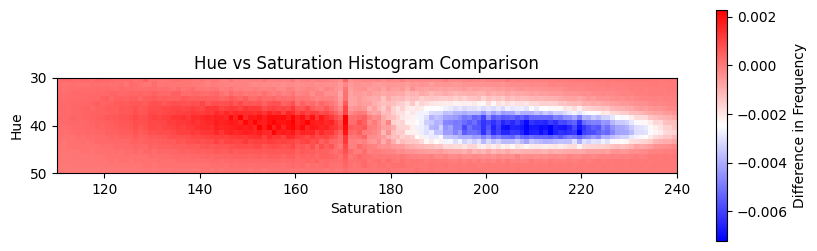

In [5]:
# plot histograms
plt.figure(figsize=(10, 3))
hue=[30, 50]
saturation=[110, 240]
# hue=[0, 180]
# saturation=[120, 254]
# plot both histograms on same plot by subtracting one from the other as 2D histogram cropped to H=[60:100] and S=[75:250]
plt.imshow((hist_0 - hist_1).reshape(180, 256)[hue[0]:hue[1], saturation[0]:saturation[1]], cmap='bwr', interpolation='nearest', extent=[saturation[0], saturation[1], hue[1], hue[0]])
plt.colorbar(label='Difference in Frequency')
plt.xlabel('Saturation')
plt.ylabel('Hue')
# plt.plot(hist_0 - hist_1, color='g', label='Difference Histogram')
plt.title('Hue vs Saturation Histogram Comparison')

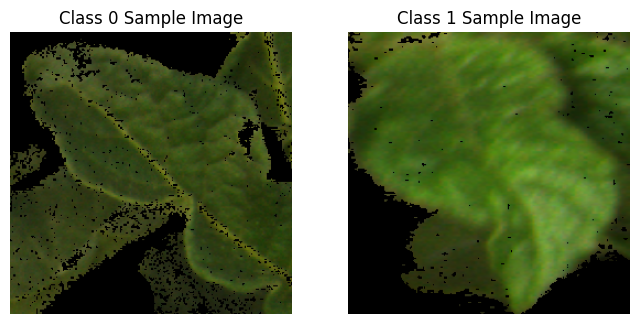

In [6]:
img0 = global_imgs[0][5]
hsv = cv2.cvtColor(img0, cv2.COLOR_RGB2HSV)
mask = (
    (hsv[:, :, 0] >= hue[0]) & (hsv[:, :, 0] <= hue[1]) &
    (hsv[:, :, 1] >= saturation[0]) & (hsv[:, :, 1] <= saturation[1])
)
img0 = img0 * mask[..., None]

img1 = global_imgs[1][5]
hsv = cv2.cvtColor(img1, cv2.COLOR_RGB2HSV)
mask = (
    (hsv[:, :, 0] >= hue[0]) & (hsv[:, :, 0] <= hue[1]) &
    (hsv[:, :, 1] >= saturation[0]) & (hsv[:, :, 1] <= saturation[1])
)
img1 = img1 * mask[..., None]
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(img0)
plt.title('Class 0 Sample Image')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(img1)
plt.title('Class 1 Sample Image')
plt.axis('off')
plt.show()

Non-zero pixels in filtered image: 39223497


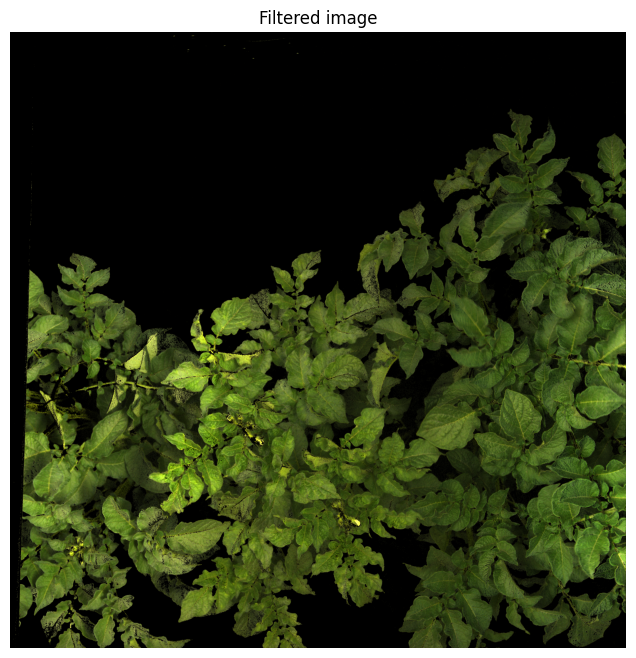

In [7]:
def parse_labels(file_path):
    parsed_data = []
    
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue  # Skip malformed lines
            label = int(parts[0])
            bbox = list(map(float, parts[1:]))  # [x_center, y_center, width, height]
            parsed_data.append((label, bbox))
    return parsed_data

from matplotlib.patches import Circle

# Display an image with its filtered version based on hue and saturation constraints
# fig, axes = plt.subplots(1, 2, figsize=(12, 5))
img = cv2.imread('Croptimal/2024_5_13_CleansingDataset/Run1_light_normal_otherobjects/test/4e8ef493-3884-4645-82c6-4291a576684d.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

labels = parse_labels("Croptimal/2024_5_13_CleansingDataset/Run1_light_normal_otherobjects/test/4e8ef493-3884-4645-82c6-4291a576684d.txt")

# Original image
# axes[0].imshow(img)
# axes[0].set_title('Original Image')
# axes[0].axis('off')

hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
# hsv = hsv.astype(np.float32)

# hue_min, hue_max = hue[0]*2, hue[1]*2
# sat_min, sat_max = saturation[0]/255, saturation[1]/255

mask = (
    (hsv[:, :, 0] >= hue[0]) & (hsv[:, :, 0] <= hue[1]) &
    (hsv[:, :, 1] >= saturation[0]) & (hsv[:, :, 1] <= saturation[1])
)

# Convert boolean mask to float (0.0 or 1.0)
# mask_f = mask_f.astype(np.float32)

# Apply mask (broadcast across RGB channels)
filtered_img = img * mask[..., None]

# print amount of non-zero pixels in filtered_img
print(f'Non-zero pixels in filtered image: {np.count_nonzero(filtered_img)}')

# axes[1].imshow(filtered_img)
# axes[1].set_title(f'Filtered Image (H:[{hue[0]}, {hue[1]}], S:[{saturation[0]}, {saturation[1]}])')
# axes[1].axis('off')

# plt.tight_layout()
# plt.show()

ig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(filtered_img)
ax.set_title('Filtered image')
ax.axis('off')

# for label, bbox in labels:
#     x_center, y_center, width, height = bbox
#     x_center = int(x_center * img.shape[1])
#     y_center = int(y_center * img.shape[0])
#     width = int(width * img.shape[1])
#     height = int(height * img.shape[0])
#     x1 = int(x_center - width / 2)
#     y1 = int(y_center - height / 2)
#     x2 = int(x_center + width / 2)
#     y2 = int(y_center + height / 2)
#     color = 'cyan' if not label else 'yellow'
#     rect = plt.Rectangle((x1, y1), width, height, linewidth=1, edgecolor='none', facecolor=color, alpha=0.25)
#     ax.add_patch(rect)

# Draw a circle around each non-zero pixel in the filtered image
# ys, xs = np.nonzero(mask)  # get coordinates of nonzero pixels
# for x, y in zip(xs, ys):
#     circ = Circle((x, y), radius=100, color='red', fill=False, linewidth=2)
#     ax.add_patch(circ)

plt.show()

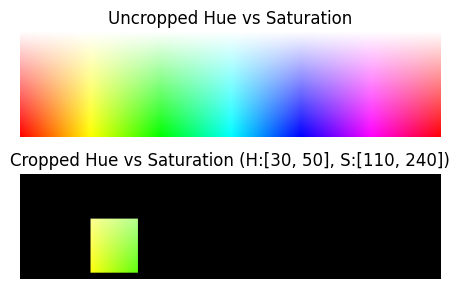

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(6, 3))

# OpenCV-compatible HSV ranges
hue2 = np.linspace(0, 360, 400, endpoint=False, dtype=np.float32)
sat2 = np.linspace(0, 1, 100, dtype=np.float32)
val = 1 * np.ones((100, 400), dtype=np.float32)

x, y = np.meshgrid(hue2, sat2)
hsv = np.stack((x, y, val), axis=2).astype(np.float32)


# Convert to RGB for display
img = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

axes[0].imshow(img)
axes[0].set_title('Uncropped Hue vs Saturation')
axes[0].axis('off')

hue_min, hue_max = hue[0]*2, hue[1]*2
sat_min, sat_max = saturation[0]/255, saturation[1]/255

mask_f = (
    (hsv[:,:,0] >= hue_min) & (hsv[:,:,0] <= hue_max) &
    (hsv[:,:,1] >= sat_min) & (hsv[:,:,1] <= sat_max)
)

# Convert boolean mask to float (0.0 or 1.0)
mask_f = mask_f.astype(np.float32)

# Apply mask (broadcast across RGB channels)
filtered_img = img * mask_f[..., None]

axes[1].imshow(filtered_img)
axes[1].set_title(
    f'Cropped Hue vs Saturation (H:[{hue[0]}, {hue[1]}], S:[{saturation[0]}, {saturation[1]}])'
)
axes[1].axis('off')

plt.tight_layout()
plt.show()
